# 22A PatchCore EfficientNet-B1 One-Layer All-in-One x240

This notebook adapts the external EfficientNet-B1 PatchCore prototype to the repo's report-compatible anomaly protocol.

What it does in one run:

- reads raw `LSWMD.pkl`
- rebuilds the shared `40k / 5k / 5k + 250` split used throughout `REPORT.md`
- fits a one-layer `EfficientNet-B1` PatchCore model on train-normal wafers only
- applies the same deployment threshold rule used across the repo:
  - threshold = `95th` percentile of validation-normal raw scores
- reevaluates the same fitted checkpoint on the secondary `70k` normal / `3.5k` defect holdout
- exports post-hoc UMAP diagnostics from the main benchmark checkpoint
- saves CSV, JSON, plot, and checkpoint artifacts under `artifacts/x240/patchcore_efficientnet_b1_one_layer`

Notes:

- this keeps the evaluation method comparable to the report while changing the model family to a new EfficientNet-B1 one-layer PatchCore follow-up
- direct threshold tuning on defect labels is intentionally not used here
- UMAP-KNN analysis is calibrated from normal-only validation data as an alternative geometry-aware thresholding view


## Submission Context

- Dataset notebook: `data/dataset/x240/benchmark_50k_5pct/notebook.ipynb`
- Dataset config: `data/dataset/x240/benchmark_50k_5pct/data_config.toml`
- Experiment config: `embedded in notebook`
- Artifact root: `experiments/anomaly_detection/patchcore/efficientnet_b1/x240/main/artifacts/`
- Notes:
  - This notebook rebuilds the x240 benchmark internally and also reevaluates on the x64 secondary holdout after fitting the main model.


In [5]:
from __future__ import annotations

import copy
import os
import json
import pickle
import random
import sys
import time
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import pandas.core.indexes as core_indexes
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.neighbors import NearestNeighbors
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from torchvision.models import EfficientNet_B1_Weights, efficientnet_b1

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")


LABEL_NORMAL = "none"
LABEL_DEFECT = "pattern"


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / ".git").exists() or ((candidate / "artifacts").exists() and (candidate / "notebooks").exists()):
            return candidate.resolve()
    return Path.cwd().resolve()


PROJECT_ROOT = find_project_root()

SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from wafer_defect.evaluation import export_reference_umap_bundle


def resolve_project_path(path_str: str | Path) -> Path:
    path = Path(path_str)
    if path.is_absolute():
        return path.resolve()
    return (PROJECT_ROOT / path).resolve()


def auto_find_raw_pickle(path_str: str | Path) -> Path:
    candidate = Path(path_str)
    candidates = []
    if candidate.is_absolute():
        candidates.append(candidate)
    else:
        candidates.extend([
            candidate,
            resolve_project_path(candidate),
            PROJECT_ROOT / "data" / "raw" / candidate.name,
        ])

    for item in candidates:
        if item.exists():
            return item.resolve()

    recursive_hits = list((PROJECT_ROOT / "data").rglob(candidate.name)) if (PROJECT_ROOT / "data").exists() else []
    if recursive_hits:
        return recursive_hits[0].resolve()

    raise FileNotFoundError(f"Raw pickle not found. Tried: {[str(x) for x in candidates]}")


CONFIG: dict[str, Any] = {

    "run": {
        "variant_name": "effnet_b1_one_layer_patchcore_x240",
        "raw_pickle": "data/raw/LSWMD.pkl",
        "output_dir": "artifacts/x240/patchcore_efficientnet_b1_one_layer",
        "seed": 42,
        "rebuild_dataset": False,
    },
    "split": {
        "image_size": 240,
        "train_normal_count": 40_000,
        "val_normal_count": 5_000,
        "test_normal_count": 5_000,
        "test_defect_fraction_of_test_normals": 0.05,
    },
    "model": {
        "device": "auto",
        "model_input_size": 240,
        "batch_size": 96,
        "num_workers": 0,
        "persistent_workers": False,
        "prefetch_factor": 2,
        "memory_bank_max_patches": 240_000,
        "score_chunk": 1024,
        "patchcore_nn_k": 3,
        "topk_patch_ratio": 0.03,
        "effnet_feature_idx": 3,
        "patch_embed_dim": 512,
        "amp": True,
    },
    "scoring": {
        "threshold_quantile": 0.95,
    },
}


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)



def resolve_device(device_name: str) -> torch.device:
    if device_name == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device_name)


def resolve_loader_workers(requested_workers: int) -> int:
    # Windows notebook kernels often fail to pickle these large in-memory array datasets.
    if os.name == "nt":
        return 0
    return max(0, int(requested_workers))


def read_legacy_pickle(path: str | Path) -> pd.DataFrame:
    sys.modules["pandas.indexes"] = core_indexes
    with Path(path).open("rb") as handle:
        return pickle.load(handle, encoding="latin1")


def unwrap_legacy_value(value: Any) -> str:
    if value is None:
        return ""
    if hasattr(value, "size") and getattr(value, "size") == 0:
        return ""
    if hasattr(value, "tolist"):
        value = value.tolist()
    while isinstance(value, list) and len(value) == 1:
        value = value[0]
    return str(value).strip()


def normalize_map(wafer_map: np.ndarray, image_size: int) -> np.ndarray:
    wafer_map = np.asarray(wafer_map, dtype=np.float32) / 2.0
    tensor = torch.from_numpy(wafer_map).unsqueeze(0).unsqueeze(0)
    return F.interpolate(tensor, size=(image_size, image_size), mode="nearest").squeeze(0).squeeze(0).numpy()


def infer_label_from_row(row: pd.Series) -> str | None:
    failure = unwrap_legacy_value(row.get("failureType", "")).lower()
    if failure == "none":
        return LABEL_NORMAL
    if failure:
        return LABEL_DEFECT
    return None


def build_split_from_raw(config: dict[str, Any]) -> dict[str, np.ndarray]:
    raw_path = auto_find_raw_pickle(config["run"]["raw_pickle"])

    image_size = int(config["split"]["image_size"])
    train_n = int(config["split"]["train_normal_count"])
    val_n = int(config["split"]["val_normal_count"])
    test_n = int(config["split"]["test_normal_count"])
    defect_fraction = float(config["split"]["test_defect_fraction_of_test_normals"])
    requested_defects = max(1, int(round(test_n * defect_fraction)))
    seed = int(config["run"]["seed"])

    df = read_legacy_pickle(raw_path).copy()
    df["failureTypeText"] = df["failureType"].map(unwrap_legacy_value)
    df["label"] = df.apply(infer_label_from_row, axis=1)
    df = df[df["label"].notna()].reset_index(drop=True)

    normal_df = df[df["label"] == LABEL_NORMAL].sample(frac=1.0, random_state=seed).reset_index(drop=True)
    defect_df = df[df["label"] == LABEL_DEFECT].sample(frac=1.0, random_state=seed).reset_index(drop=True)

    required_normals = train_n + val_n + test_n
    if len(normal_df) < required_normals:
        raise ValueError(f"Need {required_normals} normals but found {len(normal_df)}")
    if len(defect_df) < requested_defects:
        raise ValueError(f"Need {requested_defects} defects but found {len(defect_df)}")

    train_df = normal_df.iloc[:train_n].copy()
    val_df = normal_df.iloc[train_n : train_n + val_n].copy()
    test_normal_df = normal_df.iloc[train_n + val_n : train_n + val_n + test_n].copy()
    test_defect_df = defect_df.iloc[:requested_defects].copy()
    test_df = pd.concat([test_normal_df, test_defect_df], ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)

    print(
        "Prepared split | "
        f"train normals={len(train_df)} | "
        f"val normals={len(val_df)} | "
        f"test normals={len(test_normal_df)} | "
        f"test defects={len(test_defect_df)}"
    )

    def to_arrays(frame: pd.DataFrame, split_name: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        arrays = np.stack(
            [
                normalize_map(np.asarray(row["waferMap"]), image_size=image_size)
                for _, row in tqdm(frame.iterrows(), total=len(frame), desc=f"prepare_{split_name}", leave=True)
            ]
        )
        labels = (frame["label"].values == LABEL_DEFECT).astype(np.int64)
        defect_types = frame["failureTypeText"].fillna("unlabeled").replace("", "unlabeled").to_numpy()
        return arrays, labels, defect_types

    train_x, train_y, train_defect_types = to_arrays(train_df, "train")
    val_x, val_y, val_defect_types = to_arrays(val_df, "val")
    test_x, test_y, test_defect_types = to_arrays(test_df, "test")

    return {
        "train_x": train_x,
        "train_y": train_y,
        "train_defect_types": train_defect_types,
        "val_x": val_x,
        "val_y": val_y,
        "val_defect_types": val_defect_types,
        "test_x": test_x,
        "test_y": test_y,
        "test_defect_types": test_defect_types,
    }


class EfficientNetArrayDataset(Dataset):
    def __init__(self, arrays: np.ndarray, labels: np.ndarray, model_input_size: int) -> None:
        self.arrays = arrays.astype(np.float32)
        self.labels = labels.astype(np.int64)
        self.model_input_size = int(model_input_size)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        x = torch.from_numpy(self.arrays[index])
        states = torch.clamp(torch.round(x * 2.0), 0, 2).to(dtype=torch.long)
        one_hot = F.one_hot(states, num_classes=3).permute(2, 0, 1).to(dtype=torch.float32)
        if one_hot.shape[-1] != self.model_input_size or one_hot.shape[-2] != self.model_input_size:
            one_hot = F.interpolate(
                one_hot.unsqueeze(0),
                size=(self.model_input_size, self.model_input_size),
                mode="nearest",
            ).squeeze(0)
        y = torch.tensor(int(self.labels[index]), dtype=torch.long)
        return one_hot, y



class EfficientNetB1OneLayerPatchCoreModel(nn.Module):
    def __init__(
        self,
        *,
        model_input_size: int,
        feature_idx: int,
        patch_embed_dim: int,
        topk_ratio: float,
        nn_k: int,
        query_chunk_size: int,
        amp_enabled: bool,
    ) -> None:
        super().__init__()
        backbone = efficientnet_b1(weights=EfficientNet_B1_Weights.DEFAULT)
        self.features = backbone.features
        self.feature_idx = int(feature_idx)
        self.patch_embed_dim = int(patch_embed_dim)
        self.topk_ratio = float(topk_ratio)
        self.nn_k = int(nn_k)
        self.query_chunk_size = int(query_chunk_size)
        self.amp_enabled = bool(amp_enabled)

        with torch.inference_mode():
            dummy = torch.zeros(1, 3, model_input_size, model_input_size)
            x = dummy
            selected = None
            for i, block in enumerate(self.features):
                x = block(x)
                if i == self.feature_idx:
                    selected = x
                    break

        if selected is None:
            raise ValueError(f"Invalid EfficientNet-B1 feature index: {self.feature_idx}")

        in_dim = int(selected.shape[1])
        self.patch_grid = tuple(int(dim) for dim in selected.shape[-2:])
        self.feature_dim = self.patch_embed_dim
        self.proj = nn.Linear(in_dim, self.patch_embed_dim, bias=False)
        self.register_buffer("memory_bank", torch.empty(0, self.feature_dim))

        for parameter in self.features.parameters():
            parameter.requires_grad_(False)
        for parameter in self.proj.parameters():
            parameter.requires_grad_(False)

    @property
    def patches_per_image(self) -> int:
        return int(self.patch_grid[0] * self.patch_grid[1])

    def forward_feature_map(self, x: torch.Tensor) -> torch.Tensor:
        selected = None
        for i, block in enumerate(self.features):
            x = block(x)
            if i == self.feature_idx:
                selected = x
                break
        if selected is None:
            raise RuntimeError("Failed to collect EfficientNet-B1 feature map.")
        return selected

    def patch_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        amp_enabled = self.amp_enabled and x.device.type == "cuda"
        with torch.inference_mode():
            with torch.autocast(device_type=x.device.type, dtype=torch.float16, enabled=amp_enabled):
                feat = self.forward_feature_map(x)
                emb = feat.permute(0, 2, 3, 1).reshape(-1, feat.shape[1])
                emb = self.proj(emb)
            emb = F.normalize(emb.float(), p=2, dim=1)
        return emb.reshape(x.shape[0], self.patches_per_image, self.feature_dim)

    def image_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        return self.patch_embeddings(x).mean(dim=1)

    def set_memory_bank(self, memory_bank: torch.Tensor) -> None:
        if memory_bank.ndim != 2 or memory_bank.shape[1] != self.feature_dim:
            raise ValueError(
                f"memory_bank must have shape (N, {self.feature_dim}), got {tuple(memory_bank.shape)}"
            )
        normalized = F.normalize(memory_bank.to(dtype=torch.float32), p=2, dim=1)
        self.memory_bank = normalized.to(device=self.memory_bank.device, dtype=self.memory_bank.dtype)

    def nearest_patch_distances(self, patch_embeddings: torch.Tensor) -> torch.Tensor:
        if self.memory_bank.numel() == 0:
            raise ValueError("memory_bank is empty.")

        batch_size, patch_count, _ = patch_embeddings.shape
        flat_queries = patch_embeddings.reshape(-1, self.feature_dim)
        bank_t = self.memory_bank.t().contiguous()
        outputs = []

        for start in range(0, flat_queries.shape[0], self.query_chunk_size):
            query_chunk = flat_queries[start : start + self.query_chunk_size]
            sim = query_chunk @ bank_t
            k = min(self.nn_k, sim.shape[1])
            best_sim = sim.topk(k=k, dim=1).values
            dist = torch.sqrt(torch.clamp(2.0 - 2.0 * best_sim, min=0.0))
            outputs.append(dist.mean(dim=1))

        return torch.cat(outputs, dim=0).reshape(batch_size, patch_count)

    def reduce_patch_distances(self, patch_distances: torch.Tensor) -> torch.Tensor:
        topk = max(1, int(round(patch_distances.shape[1] * self.topk_ratio)))
        topk = min(topk, patch_distances.shape[1])
        return torch.topk(patch_distances, k=topk, dim=1).values.mean(dim=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        patch_embeddings = self.patch_embeddings(x)
        patch_distances = self.nearest_patch_distances(patch_embeddings)
        return self.reduce_patch_distances(patch_distances)


def prepare_output_dir(config: dict[str, Any]) -> Path:
    output_dir = resolve_project_path(config["run"]["output_dir"])
    output_dir.mkdir(parents=True, exist_ok=True)
    return output_dir


def dataset_cache_path(config: dict[str, Any]) -> Path:
    return prepare_output_dir(config) / "dataset_cache.npz"


def save_dataset_cache(dataset: dict[str, np.ndarray], cache_path: Path) -> None:
    np.savez_compressed(cache_path, **dataset)
    print(f"Saved dataset cache to {cache_path}")


def load_dataset_cache(cache_path: Path) -> dict[str, np.ndarray]:
    cached = np.load(cache_path, allow_pickle=True)
    dataset = {key: cached[key] for key in cached.files}
    print(f"Loaded dataset cache from {cache_path}")
    return dataset


def prepare_dataset(config: dict[str, Any], rebuild: bool = False) -> dict[str, np.ndarray]:
    set_seed(int(config["run"]["seed"]))
    cache_path = dataset_cache_path(config)
    if cache_path.exists() and not rebuild:
        return load_dataset_cache(cache_path)
    dataset = build_split_from_raw(config)
    save_dataset_cache(dataset, cache_path)
    return dataset


def make_loaders(dataset: dict[str, np.ndarray], config: dict[str, Any], device: torch.device) -> dict[str, DataLoader]:
    bs = int(config["model"]["batch_size"])
    requested_nw = int(config["model"]["num_workers"])
    nw = resolve_loader_workers(requested_nw)
    pin = device.type == "cuda"
    model_input_size = int(config["model"]["model_input_size"])
    if nw != requested_nw:
        print({
            "requested_num_workers": requested_nw,
            "effective_num_workers": nw,
            "reason": "Windows notebook fallback for in-memory dataset pickling",
        })
    loader_kwargs: dict[str, Any] = {
        "batch_size": bs,
        "num_workers": nw,
        "pin_memory": pin,
    }
    if nw > 0:
        loader_kwargs["persistent_workers"] = bool(config["model"].get("persistent_workers", True))
        loader_kwargs["prefetch_factor"] = int(config["model"].get("prefetch_factor", 2))
    return {
        "train": DataLoader(EfficientNetArrayDataset(dataset["train_x"], dataset["train_y"], model_input_size), shuffle=False, **loader_kwargs),
        "val": DataLoader(EfficientNetArrayDataset(dataset["val_x"], dataset["val_y"], model_input_size), shuffle=False, **loader_kwargs),
        "test": DataLoader(EfficientNetArrayDataset(dataset["test_x"], dataset["test_y"], model_input_size), shuffle=False, **loader_kwargs),
    }


def collect_memory_bank(
    model: EfficientNetB1OneLayerPatchCoreModel,
    loader: DataLoader,
    device: torch.device,
    target_size: int,
    seed: int,
) -> torch.Tensor:
    if target_size <= 0:
        raise ValueError("target_size must be positive")

    patch_batches: list[torch.Tensor] = []
    total_seen_patches = 0
    estimated_total_patches = model.patches_per_image * len(loader.dataset)
    sample_ratio = min(1.0, target_size / estimated_total_patches)
    generator = torch.Generator().manual_seed(seed)

    print(
        {
            "estimated_total_patches": int(estimated_total_patches),
            "sample_ratio": round(sample_ratio, 6),
        }
    )

    model.eval()
    progress = tqdm(loader, desc="memory_bank", total=len(loader), leave=True)
    with torch.inference_mode():
        for inputs, labels in progress:
            inputs = inputs.to(device, non_blocking=device.type == "cuda")
            labels = labels.to(device)
            normal_mask = labels == 0
            if not torch.any(normal_mask):
                continue

            embeddings = model.patch_embeddings(inputs[normal_mask]).reshape(-1, model.feature_dim)
            total_seen_patches += int(embeddings.shape[0])
            embeddings = embeddings.cpu()

            if sample_ratio < 1.0:
                keep_n = max(1, int(round(embeddings.shape[0] * sample_ratio)))
                keep_idx = torch.randperm(embeddings.shape[0], generator=generator)[:keep_n]
                embeddings = embeddings[keep_idx]

            patch_batches.append(embeddings)
            progress.set_postfix(seen_patches=total_seen_patches, kept_batches=len(patch_batches))

    if not patch_batches:
        raise ValueError("Could not build memory bank because no normal embeddings were collected.")

    memory_bank = torch.cat(patch_batches, dim=0)
    print({"observed_raw_patches": int(total_seen_patches), "sampled_before_trim": int(memory_bank.shape[0])})

    if memory_bank.shape[0] > target_size:
        keep_gen = torch.Generator().manual_seed(seed)
        keep = torch.randperm(memory_bank.shape[0], generator=keep_gen)[:target_size]
        memory_bank = memory_bank[keep]

    return memory_bank


def collect_scores(
    model: EfficientNetB1OneLayerPatchCoreModel,
    loader: DataLoader,
    device: torch.device,
    desc: str,
) -> pd.DataFrame:
    rows = []
    model.eval()
    progress = tqdm(loader, desc=desc, total=len(loader), leave=True)
    with torch.inference_mode():
        for inputs, labels in progress:
            inputs = inputs.to(device, non_blocking=device.type == "cuda")
            scores = model(inputs).cpu().numpy()
            labels = labels.cpu().numpy()
            for score, label in zip(scores, labels):
                rows.append({"score": float(score), "is_anomaly": int(label)})
            progress.set_postfix(rows=len(rows))
    return pd.DataFrame(rows)


def summarize_threshold_metrics(labels: np.ndarray, scores: np.ndarray, threshold: float) -> dict[str, Any]:
    scores = np.nan_to_num(scores, nan=0.0, posinf=1e6, neginf=0.0)
    predicted = (scores > threshold).astype(int)
    tp = int(((predicted == 1) & (labels == 1)).sum())
    fp = int(((predicted == 1) & (labels == 0)).sum())
    tn = int(((predicted == 0) & (labels == 0)).sum())
    fn = int(((predicted == 0) & (labels == 1)).sum())
    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    f1 = 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)
    return {
        "threshold": float(threshold),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auroc": float(roc_auc_score(labels, scores)),
        "auprc": float(average_precision_score(labels, scores)),
        "predicted_anomalies": int(predicted.sum()),
        "confusion_matrix": [[tn, fp], [fn, tp]],
    }


def sweep_threshold_metrics(labels: np.ndarray, scores: np.ndarray) -> tuple[pd.DataFrame, dict[str, Any]]:
    scores = np.nan_to_num(scores, nan=0.0, posinf=1e6, neginf=0.0)
    thresholds = np.unique(scores)
    rows = []
    for threshold in thresholds:
        metrics = summarize_threshold_metrics(labels, scores, float(threshold))
        rows.append(
            {
                "threshold": float(threshold),
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "predicted_anomalies": metrics["predicted_anomalies"],
            }
        )
    sweep_df = pd.DataFrame(rows).sort_values(["f1", "recall", "precision", "threshold"], ascending=[False, False, False, True]).reset_index(drop=True)
    best_row = sweep_df.iloc[0].to_dict()
    return sweep_df, best_row


def build_defect_breakdown(defect_types: np.ndarray, labels: np.ndarray, scores: np.ndarray, threshold: float) -> pd.DataFrame:
    eval_df = pd.DataFrame(
        {
            "defect_type": defect_types,
            "is_anomaly": labels.astype(int),
            "score": scores,
        }
    )
    eval_df["predicted_anomaly"] = (eval_df["score"] > threshold).astype(int)
    defect_only = eval_df[eval_df["is_anomaly"] == 1].copy()
    grouped = defect_only.groupby("defect_type").agg(
        count=("defect_type", "size"),
        detected=("predicted_anomaly", "sum"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
    )
    grouped["missed"] = grouped["count"] - grouped["detected"]
    grouped["recall"] = grouped["detected"] / grouped["count"].clip(lower=1)
    return grouped.sort_values(["recall", "count", "mean_score"], ascending=[True, False, True]).reset_index()


def run_variant(dataset: dict[str, np.ndarray], config: dict[str, Any]) -> dict[str, Any]:
    set_seed(int(config["run"]["seed"]))
    device = resolve_device(str(config["model"]["device"]))
    loaders = make_loaders(dataset, config, device)
    model = EfficientNetB1OneLayerPatchCoreModel(
        model_input_size=int(config["model"]["model_input_size"]),
        feature_idx=int(config["model"]["effnet_feature_idx"]),
        patch_embed_dim=int(config["model"]["patch_embed_dim"]),
        topk_ratio=float(config["model"]["topk_patch_ratio"]),
        nn_k=int(config["model"]["patchcore_nn_k"]),
        query_chunk_size=int(config["model"]["score_chunk"]),
        amp_enabled=bool(config["model"]["amp"]),
    ).to(device).eval()

    build_start = time.perf_counter()
    memory_bank = collect_memory_bank(
        model=model,
        loader=loaders["train"],
        device=device,
        target_size=int(config["model"]["memory_bank_max_patches"]),
        seed=int(config["run"]["seed"]),
    )
    model.set_memory_bank(memory_bank.to(device))
    build_seconds = time.perf_counter() - build_start

    score_val_start = time.perf_counter()
    val_scores_df = collect_scores(model, loaders["val"], device, desc="score_val")
    score_val_seconds = time.perf_counter() - score_val_start

    score_test_start = time.perf_counter()
    test_scores_df = collect_scores(model, loaders["test"], device, desc="score_test")
    score_test_seconds = time.perf_counter() - score_test_start

    val_normal_scores = val_scores_df.loc[val_scores_df["is_anomaly"] == 0, "score"].to_numpy()
    threshold = float(np.quantile(val_normal_scores, float(config["scoring"]["threshold_quantile"])))
    labels = test_scores_df["is_anomaly"].to_numpy()
    scores = test_scores_df["score"].to_numpy()
    metrics = summarize_threshold_metrics(labels, scores, threshold)
    threshold_sweep_df, best_sweep = sweep_threshold_metrics(labels, scores)
    defect_breakdown_df = build_defect_breakdown(dataset["test_defect_types"], labels, scores, threshold)

    summary = {
        "variant": str(config["run"]["variant_name"]),
        "name": "PatchCore-EfficientNetB1-OneLayer-x240",
        "threshold_policy": "val_normal_quantile_raw",
        "threshold_quantile": float(config["scoring"]["threshold_quantile"]),
        "threshold": float(threshold),
        "precision": float(metrics["precision"]),
        "recall": float(metrics["recall"]),
        "f1": float(metrics["f1"]),
        "auroc": float(metrics["auroc"]),
        "auprc": float(metrics["auprc"]),
        "best_sweep_threshold": float(best_sweep["threshold"]),
        "best_sweep_precision": float(best_sweep["precision"]),
        "best_sweep_recall": float(best_sweep["recall"]),
        "best_sweep_f1": float(best_sweep["f1"]),
        "predicted_anomalies": int(metrics["predicted_anomalies"]),
        "memory_bank_size": int(model.memory_bank.shape[0]),
        "patches_per_image": int(model.patches_per_image),
        "feature_dim": int(model.feature_dim),
        "patch_grid_h": int(model.patch_grid[0]),
        "patch_grid_w": int(model.patch_grid[1]),
        "build_seconds": float(build_seconds),
        "score_val_seconds": float(score_val_seconds),
        "score_test_seconds": float(score_test_seconds),
        "device": str(device),
        "config": copy.deepcopy(config),
    }

    return {
        "score_df": pd.DataFrame([summary]),
        "summary": summary,
        "val_scores_df": val_scores_df,
        "test_scores_df": test_scores_df,
        "threshold_sweep_df": threshold_sweep_df,
        "defect_breakdown_df": defect_breakdown_df,
        "checkpoint": {
            "model_state_dict": model.state_dict(),
            "memory_bank": model.memory_bank.detach().cpu(),
            "summary": summary,
        },
    }


def save_variant_result(output_dir: Path, variant_name: str, result: dict[str, Any]) -> None:
    result["score_df"].to_csv(output_dir / f"{variant_name}_best_row.csv", index=False)
    result["val_scores_df"].to_csv(output_dir / f"{variant_name}_val_scores.csv", index=False)
    result["test_scores_df"].to_csv(output_dir / f"{variant_name}_test_scores.csv", index=False)
    result["threshold_sweep_df"].to_csv(output_dir / f"{variant_name}_threshold_sweep.csv", index=False)
    result["defect_breakdown_df"].to_csv(output_dir / f"{variant_name}_defect_breakdown.csv", index=False)
    with (output_dir / f"{variant_name}_summary.json").open("w", encoding="utf-8") as handle:
        json.dump(result["summary"], handle, indent=2)
    torch.save(result["checkpoint"], output_dir / f"{variant_name}_best_model.pt")
    pd.DataFrame([result["summary"]]).to_csv(output_dir / "variant_summary.csv", index=False)
    with (output_dir / "config_snapshot.json").open("w", encoding="utf-8") as handle:
        json.dump(result["summary"]["config"], handle, indent=2)
    print(f"Saved outputs for {variant_name} to {output_dir}")


def run_and_save_variant(dataset: dict[str, np.ndarray], config: dict[str, Any]) -> dict[str, Any]:
    output_dir = prepare_output_dir(config)
    variant_name = str(config["run"]["variant_name"])
    print(f"Running {variant_name}")
    result = run_variant(dataset, config)
    save_variant_result(output_dir, variant_name, result)
    return result


def load_saved_summary(config: dict[str, Any]) -> pd.DataFrame:
    summary_path = prepare_output_dir(config) / "variant_summary.csv"
    if not summary_path.exists():
        raise FileNotFoundError(f"Summary not found: {summary_path}")
    return pd.read_csv(summary_path)


pd.DataFrame([
    {
        "raw_pickle": CONFIG["run"]["raw_pickle"],
        "output_dir": CONFIG["run"]["output_dir"],
        "train_normals": CONFIG["split"]["train_normal_count"],
        "val_normals": CONFIG["split"]["val_normal_count"],
        "test_normals": CONFIG["split"]["test_normal_count"],
        "test_defect_fraction": CONFIG["split"]["test_defect_fraction_of_test_normals"],
        "model_input_size": CONFIG["model"]["model_input_size"],
        "batch_size": CONFIG["model"]["batch_size"],
        "num_workers": CONFIG["model"]["num_workers"],
        "persistent_workers": CONFIG["model"]["persistent_workers"],
        "prefetch_factor": CONFIG["model"]["prefetch_factor"],
        "memory_bank_max_patches": CONFIG["model"]["memory_bank_max_patches"],
        "score_chunk": CONFIG["model"]["score_chunk"],
        "patchcore_nn_k": CONFIG["model"]["patchcore_nn_k"],
        "topk_patch_ratio": CONFIG["model"]["topk_patch_ratio"],
        "effnet_feature_idx": CONFIG["model"]["effnet_feature_idx"],
        "patch_embed_dim": CONFIG["model"]["patch_embed_dim"],
        "threshold_quantile": CONFIG["scoring"]["threshold_quantile"],
    }
])


,raw_pickle,output_dir,train_normals,val_normals,test_normals,test_defect_fraction,model_input_size,batch_size,num_workers,persistent_workers,prefetch_factor,memory_bank_max_patches,score_chunk,patchcore_nn_k,topk_patch_ratio,effnet_feature_idx,patch_embed_dim,threshold_quantile
0,data/raw/LSWMD.pkl,artifacts/x240/patchcore_efficientnet_b1_one_l...,40000,5000,5000,0.05,240,96,0,False,2,240000,1024,3,0.03,3,512,0.95


In [6]:
output_dir = prepare_output_dir(CONFIG)
cache_path = dataset_cache_path(CONFIG)
raw_pickle_path = auto_find_raw_pickle(CONFIG["run"]["raw_pickle"])
dataset = prepare_dataset(CONFIG, rebuild=bool(CONFIG["run"].get("rebuild_dataset", False)))
print(f"Project root: {PROJECT_ROOT}")
print(f"Raw pickle: {raw_pickle_path}")
print(f"Output dir: {output_dir}")
print(f"Dataset cache: {cache_path}")
print({key: value.shape if hasattr(value, "shape") else type(value) for key, value in dataset.items()})
print(f"Effective loader workers: {resolve_loader_workers(int(CONFIG["model"]["num_workers"]))}")


Loaded dataset cache from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x240\patchcore_efficientnet_b1_one_layer\dataset_cache.npz
Project root: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8
Raw pickle: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\data\raw\LSWMD.pkl
Output dir: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x240\patchcore_efficientnet_b1_one_layer
Dataset cache: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x240\patchcore_efficientnet_b1_one_layer\dataset_cache.npz
{'train_x': (40000, 240, 240), 'train_y': (40000,), 'train_defect_types': (40000,), 'val_x': (5000, 240, 240), 'val_y': (5000,), 'val_defect_types': (5000,), 'test_x': (5250, 240, 240), 'test_y': (5250,), 'test_defect_types': (5250,)}
Effective loader workers: 0


In [4]:
result = run_and_save_variant(dataset, CONFIG)
display(result["score_df"])
display(result["defect_breakdown_df"].head(12))


Running effnet_b1_one_layer_patchcore_x240


KeyboardInterrupt: 

In [10]:
summary_df = load_saved_summary(CONFIG)
variant_name = str(CONFIG["run"]["variant_name"])
print(f"Best-row CSV: {output_dir / f'{variant_name}_best_row.csv'}")
print(f"Validation-score CSV: {output_dir / f'{variant_name}_val_scores.csv'}")
print(f"Test-score CSV: {output_dir / f'{variant_name}_test_scores.csv'}")
print(f"Threshold-sweep CSV: {output_dir / f'{variant_name}_threshold_sweep.csv'}")
print(f"Defect-breakdown CSV: {output_dir / f'{variant_name}_defect_breakdown.csv'}")
print(f"Checkpoint: {output_dir / f'{variant_name}_best_model.pt'}")
display(summary_df)


Best-row CSV: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x240\patchcore_efficientnet_b1_one_layer\effnet_b1_one_layer_patchcore_x240_best_row.csv
Validation-score CSV: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x240\patchcore_efficientnet_b1_one_layer\effnet_b1_one_layer_patchcore_x240_val_scores.csv
Test-score CSV: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x240\patchcore_efficientnet_b1_one_layer\effnet_b1_one_layer_patchcore_x240_test_scores.csv
Threshold-sweep CSV: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x240\patchcore_efficientnet_b1_one_layer\effnet_b1_one_layer_patchcore_x240_threshold_sweep.csv
Defect-breakdown CSV: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x240\patchcore_efficientnet_b1_one_layer\effnet_b1_one_layer_patchcore_x240_defect_breakdown.csv
Checkpoint: C:\Users\User\Desktop\T

,variant,name,threshold_policy,threshold_quantile,threshold,precision,recall,f1,auroc,auprc,...,memory_bank_size,patches_per_image,feature_dim,patch_grid_h,patch_grid_w,build_seconds,score_val_seconds,score_test_seconds,device,config
0,effnet_b1_one_layer_patchcore_x240,PatchCore-EfficientNetB1-OneLayer-x240,val_normal_quantile_raw,0.95,0.508706,0.47561,0.78,0.590909,0.935394,0.608698,...,240000,900,512,30,30,106.731094,168.253098,179.945437,cuda,{'run': {'variant_name': 'effnet_b1_one_layer_...


In [11]:
# Secondary holdout reevaluation: disabled by default for x240 because building a full
# 70k normal / 3.5k defect in-memory array cache is very RAM-heavy.
RUN_HOLDOUT_EVALUATION = True

if not RUN_HOLDOUT_EVALUATION:
    print(
        "Holdout evaluation skipped by default for 22A x240. "
        "The previous error came from trying to allocate the full in-memory holdout arrays. "
        "Use the main benchmark first, or rewrite the holdout path to stream from saved arrays/metadata instead."
    )
else:
    holdout_config = copy.deepcopy(CONFIG)
    holdout_config["split"]["test_normal_count"] = 70_000
    holdout_config["split"]["test_defect_fraction_of_test_normals"] = 3_500 / 70_000
    holdout_dataset = build_split_from_raw(holdout_config)

    display(pd.DataFrame([
        {"split": "train", "count": len(holdout_dataset["train_y"]), "anomalies": int((holdout_dataset["train_y"] == 1).sum())},
        {"split": "val", "count": len(holdout_dataset["val_y"]), "anomalies": int((holdout_dataset["val_y"] == 1).sum())},
        {"split": "test", "count": len(holdout_dataset["test_y"]), "anomalies": int((holdout_dataset["test_y"] == 1).sum())},
    ]))

    device = resolve_device(str(holdout_config["model"]["device"]))
    holdout_loaders = make_loaders(holdout_dataset, holdout_config, device)
    holdout_model = EfficientNetB1OneLayerPatchCoreModel(
        model_input_size=int(holdout_config["model"]["model_input_size"]),
        feature_idx=int(holdout_config["model"]["effnet_feature_idx"]),
        patch_embed_dim=int(holdout_config["model"]["patch_embed_dim"]),
        topk_ratio=float(holdout_config["model"]["topk_patch_ratio"]),
        nn_k=int(holdout_config["model"]["patchcore_nn_k"]),
        query_chunk_size=int(holdout_config["model"]["score_chunk"]),
        amp_enabled=bool(holdout_config["model"]["amp"]),
    ).to(device).eval()

    checkpoint_state = result["checkpoint"]["model_state_dict"]
    if "memory_bank" in checkpoint_state:
        holdout_model.set_memory_bank(checkpoint_state["memory_bank"])
        holdout_model.load_state_dict(checkpoint_state, strict=False)
    else:
        holdout_model.load_state_dict(checkpoint_state)

    holdout_val_scores_df = collect_scores(holdout_model, holdout_loaders["val"], device, desc="score_val_holdout")
    holdout_test_scores_df = collect_scores(holdout_model, holdout_loaders["test"], device, desc="score_test_holdout")

    holdout_threshold = float(
        np.quantile(
            holdout_val_scores_df.loc[holdout_val_scores_df["is_anomaly"] == 0, "score"].to_numpy(),
            float(holdout_config["scoring"]["threshold_quantile"]),
        )
    )
    holdout_labels = holdout_test_scores_df["is_anomaly"].to_numpy()
    holdout_scores = holdout_test_scores_df["score"].to_numpy()
    holdout_metrics = summarize_threshold_metrics(holdout_labels, holdout_scores, holdout_threshold)
    holdout_threshold_sweep_df, holdout_best_sweep = sweep_threshold_metrics(holdout_labels, holdout_scores)
    holdout_defect_breakdown_df = build_defect_breakdown(
        holdout_dataset["test_defect_types"],
        holdout_labels,
        holdout_scores,
        holdout_threshold,
    )

    holdout_summary = {
        "name": result["summary"]["name"],
        "protocol": "holdout70k_3p5k",
        "threshold_policy": "val_normal_quantile_raw",
        "threshold_quantile": float(holdout_config["scoring"]["threshold_quantile"]),
        "threshold": float(holdout_threshold),
        "precision": float(holdout_metrics["precision"]),
        "recall": float(holdout_metrics["recall"]),
        "f1": float(holdout_metrics["f1"]),
        "auroc": float(holdout_metrics["auroc"]),
        "auprc": float(holdout_metrics["auprc"]),
        "best_sweep_threshold": float(holdout_best_sweep["threshold"]),
        "best_sweep_precision": float(holdout_best_sweep["precision"]),
        "best_sweep_recall": float(holdout_best_sweep["recall"]),
        "best_sweep_f1": float(holdout_best_sweep["f1"]),
        "predicted_anomalies": int(holdout_metrics["predicted_anomalies"]),
        "counts": {
            "train_normal": int((holdout_dataset["train_y"] == 0).sum()),
            "val_normal": int((holdout_dataset["val_y"] == 0).sum()),
            "test_normal": int((holdout_dataset["test_y"] == 0).sum()),
            "test_anomaly": int((holdout_dataset["test_y"] == 1).sum()),
        },
    }

    holdout_output_dir = output_dir / "holdout70k_3p5k"
    holdout_output_dir.mkdir(parents=True, exist_ok=True)
    holdout_val_scores_df.to_csv(holdout_output_dir / "val_scores.csv", index=False)
    holdout_test_scores_df.to_csv(holdout_output_dir / "test_scores.csv", index=False)
    holdout_threshold_sweep_df.to_csv(holdout_output_dir / "threshold_sweep.csv", index=False)
    holdout_defect_breakdown_df.to_csv(holdout_output_dir / "defect_breakdown.csv", index=False)
    pd.DataFrame([holdout_summary]).to_csv(holdout_output_dir / "summary.csv", index=False)
    (holdout_output_dir / "summary.json").write_text(json.dumps(holdout_summary, indent=2), encoding="utf-8")

    display(pd.DataFrame([holdout_summary]))
    display(holdout_defect_breakdown_df)
    print(f"Saved holdout artifacts to {holdout_output_dir}")


C:\Users\User\AppData\Local\Temp\ipykernel_45000\646928645.py:138: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(handle, encoding="latin1")


Prepared split | train normals=40000 | val normals=5000 | test normals=70000 | test defects=3500


prepare_train:   0%|          | 0/40000 [00:00<?, ?it/s]

prepare_val:   0%|          | 0/5000 [00:00<?, ?it/s]

prepare_test:   0%|          | 0/73500 [00:00<?, ?it/s]

,split,count,anomalies
0,train,40000,0
1,val,5000,0
2,test,73500,3500


MemoryError: Unable to allocate 15.8 GiB for an array with shape (73500, 240, 240) and data type float32

umap_val:   0%|          | 0/53 [00:00<?, ?it/s]

umap_test:   0%|          | 0/55 [00:00<?, ?it/s]

c:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


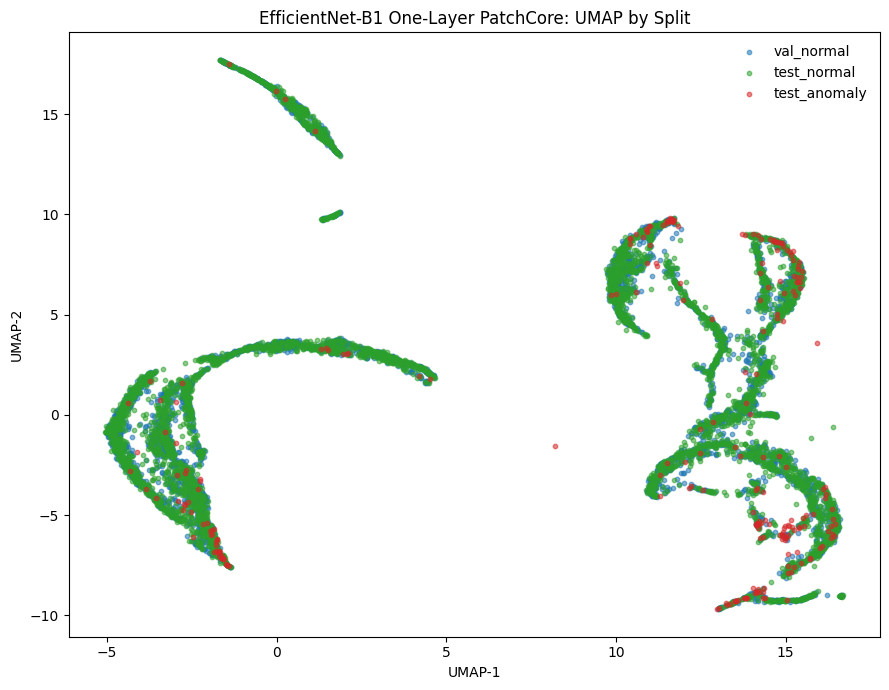

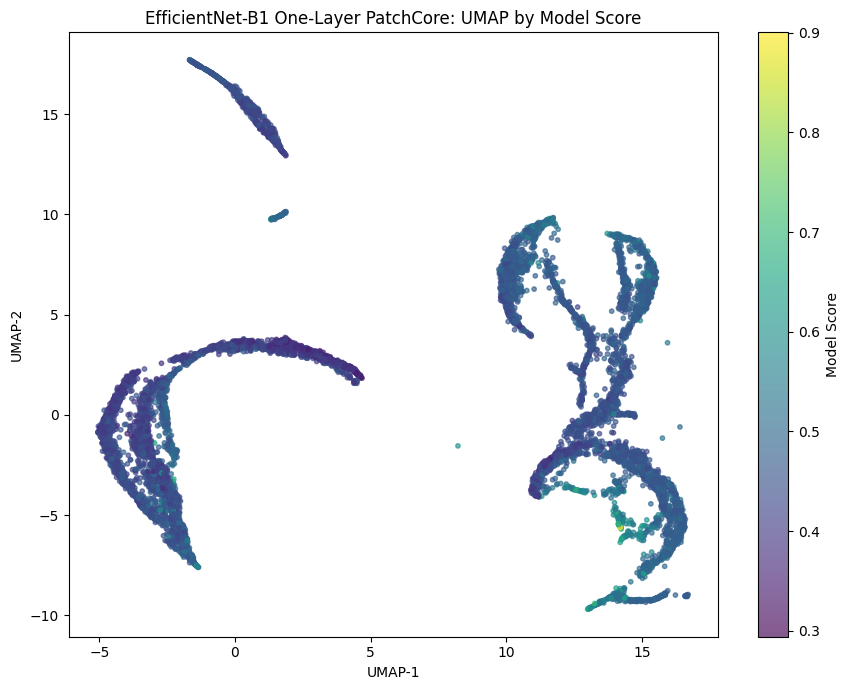

,name,threshold_quantile,umap_knn_threshold,counts.val_normal,counts.test_normal,counts.test_anomaly,umap_params.random_state,umap_params.pca_components,umap_params.n_neighbors,umap_params.min_dist,umap_params.knn_k,umap_knn_metrics.threshold,umap_knn_metrics.precision,umap_knn_metrics.recall,umap_knn_metrics.f1,umap_knn_metrics.auroc,umap_knn_metrics.auprc,umap_knn_metrics.predicted_anomalies,umap_knn_metrics.confusion_matrix
0,PatchCore-EfficientNetB1-OneLayer-x240,0.95,0.263219,5000,5000,250,42,50,15,0.1,15,0.263219,0.131737,0.176,0.150685,0.597831,0.085722,334,"[[4710, 290], [206, 44]]"


Saved UMAP artifacts to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x240\patchcore_efficientnet_b1_one_layer\evaluation


In [12]:
# Reference-fit UMAP export: train-normal manifold + validation-calibrated UMAP-KNN scores.
import matplotlib.pyplot as plt
import umap.umap_ as umap


def collect_embeddings_and_scores(model, loader, device, desc):
    embeddings_all = []
    labels_all = []
    scores_all = []
    model.eval()
    progress = tqdm(loader, desc=desc, total=len(loader), leave=True)
    with torch.inference_mode():
        for inputs, labels in progress:
            inputs = inputs.to(device, non_blocking=device.type == "cuda")
            patch_embeddings = model.patch_embeddings(inputs)
            image_embeddings = patch_embeddings.mean(dim=1)
            patch_scores = model.nearest_patch_distances(patch_embeddings)
            scores = model.reduce_patch_distances(patch_scores)
            embeddings_all.append(image_embeddings.cpu().numpy())
            labels_all.extend(labels.cpu().tolist())
            scores_all.extend(scores.cpu().tolist())
    return (
        np.concatenate(embeddings_all, axis=0),
        np.asarray(labels_all, dtype=np.int64),
        np.asarray(scores_all, dtype=np.float32),
    )


main_loaders = make_loaders(dataset, CONFIG, resolve_device(str(CONFIG["model"]["device"])))
umap_model = EfficientNetB1OneLayerPatchCoreModel(
    model_input_size=int(CONFIG["model"]["model_input_size"]),
    feature_idx=int(CONFIG["model"]["effnet_feature_idx"]),
    patch_embed_dim=int(CONFIG["model"]["patch_embed_dim"]),
    topk_ratio=float(CONFIG["model"]["topk_patch_ratio"]),
    nn_k=int(CONFIG["model"]["patchcore_nn_k"]),
    query_chunk_size=int(CONFIG["model"]["score_chunk"]),
    amp_enabled=bool(CONFIG["model"]["amp"]),
).to(resolve_device(str(CONFIG["model"]["device"]))).eval()

umap_state = result["checkpoint"]["model_state_dict"]
if "memory_bank" in umap_state:
    umap_model.set_memory_bank(umap_state["memory_bank"])
    umap_model.load_state_dict(umap_state, strict=False)
else:
    umap_model.load_state_dict(umap_state)

train_embeddings, train_labels, _ = collect_embeddings_and_scores(umap_model, main_loaders["train"], resolve_device(str(CONFIG["model"]["device"])), "umap_train")
val_embeddings, val_labels, val_scores = collect_embeddings_and_scores(umap_model, main_loaders["val"], resolve_device(str(CONFIG["model"]["device"])), "umap_val")
test_embeddings, test_labels, test_scores = collect_embeddings_and_scores(umap_model, main_loaders["test"], resolve_device(str(CONFIG["model"]["device"])), "umap_test")

evaluation_dir = output_dir / "evaluation"
plots_dir = evaluation_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

np.save(evaluation_dir / "train_embeddings.npy", train_embeddings)
np.save(evaluation_dir / "val_embeddings.npy", val_embeddings)
np.save(evaluation_dir / "test_embeddings.npy", test_embeddings)
np.save(evaluation_dir / "train_labels.npy", train_labels)
np.save(evaluation_dir / "val_labels.npy", val_labels)
np.save(evaluation_dir / "test_labels.npy", test_labels)
np.save(evaluation_dir / "val_scores.npy", val_scores)
np.save(evaluation_dir / "test_scores.npy", test_scores)

umap_bundle = export_reference_umap_bundle(
    output_dir=evaluation_dir,
    umap_module=umap,
    train_normal_embeddings=train_embeddings,
    val_embeddings=val_embeddings,
    val_labels=val_labels,
    test_embeddings=test_embeddings,
    test_labels=test_labels,
    val_model_scores=val_scores,
    test_model_scores=test_scores,
    threshold_quantile=float(CONFIG["scoring"]["threshold_quantile"]),
    random_state=42,
    pca_components=50,
    n_neighbors=15,
    min_dist=0.1,
    knn_k=15,
    metric="euclidean",
    max_train_reference=5000,
    max_val_normal=5000,
    max_test_normal=5000,
    max_test_anomaly=250,
    title_prefix="EfficientNet-B1 One-Layer PatchCore",
    points_filename="umap_points.csv",
    split_plot_filename="plots/umap_by_split.png",
    score_plot_filename="plots/umap_by_score.png",
    summary_filename="umap_summary.json",
    sweep_filename="umap_knn_threshold_sweep.csv",
)

display(pd.json_normalize(umap_bundle["summary"], sep="."))
print(f"Saved reference-fit UMAP artifacts to {evaluation_dir}")


In [ ]:
# Joint-fit UMAP: comparison-only view where val + test points jointly shape the 2D layout.
# This is useful for visual inspection, but it is less strict than the reference-fit UMAP above
# because test points influence the manifold itself.

joint_fit_dir = output_dir / "evaluation" / "joint_fit"
joint_fit_plots_dir = joint_fit_dir / "plots"
joint_fit_plots_dir.mkdir(parents=True, exist_ok=True)

saved_eval_dir = output_dir / "evaluation"
val_embeddings_path = saved_eval_dir / "val_embeddings.npy"
test_embeddings_path = saved_eval_dir / "test_embeddings.npy"
val_labels_path = saved_eval_dir / "val_labels.npy"
test_labels_path = saved_eval_dir / "test_labels.npy"
val_scores_path = saved_eval_dir / "val_scores.npy"
test_scores_path = saved_eval_dir / "test_scores.npy"

if all(path.exists() for path in [
    val_embeddings_path,
    test_embeddings_path,
    val_labels_path,
    test_labels_path,
    val_scores_path,
    test_scores_path,
]):
    val_embeddings = np.load(val_embeddings_path)
    test_embeddings = np.load(test_embeddings_path)
    val_labels = np.load(val_labels_path)
    test_labels = np.load(test_labels_path)
    val_scores = np.load(val_scores_path)
    test_scores = np.load(test_scores_path)
else:
    joint_loaders = make_loaders(dataset, CONFIG, resolve_device(str(CONFIG["model"]["device"])))
    joint_umap_model = EfficientNetB1OneLayerPatchCoreModel(
        model_input_size=int(CONFIG["model"]["model_input_size"]),
        feature_idx=int(CONFIG["model"]["effnet_feature_idx"]),
        patch_embed_dim=int(CONFIG["model"]["patch_embed_dim"]),
        topk_ratio=float(CONFIG["model"]["topk_patch_ratio"]),
        nn_k=int(CONFIG["model"]["patchcore_nn_k"]),
        query_chunk_size=int(CONFIG["model"]["score_chunk"]),
        amp_enabled=bool(CONFIG["model"]["amp"]),
    ).to(resolve_device(str(CONFIG["model"]["device"]))).eval()

    joint_umap_state = result["checkpoint"]["model_state_dict"]
    if "memory_bank" in joint_umap_state:
        joint_umap_model.set_memory_bank(joint_umap_state["memory_bank"])
        joint_umap_model.load_state_dict(joint_umap_state, strict=False)
    else:
        joint_umap_model.load_state_dict(joint_umap_state)

    val_embeddings, val_labels, val_scores = collect_embeddings_and_scores(
        joint_umap_model,
        joint_loaders["val"],
        resolve_device(str(CONFIG["model"]["device"])),
        "umap_joint_val",
    )
    test_embeddings, test_labels, test_scores = collect_embeddings_and_scores(
        joint_umap_model,
        joint_loaders["test"],
        resolve_device(str(CONFIG["model"]["device"])),
        "umap_joint_test",
    )

joint_embeddings = np.concatenate([val_embeddings, test_embeddings], axis=0)
joint_groups = np.concatenate([
    np.where(val_labels == 0, "val_normal", "val_anomaly"),
    np.where(test_labels == 0, "test_normal", "test_anomaly"),
])
joint_is_anomaly = np.concatenate([val_labels.astype(int), test_labels.astype(int)], axis=0)
joint_model_scores = np.concatenate([val_scores.astype(float), test_scores.astype(float)], axis=0)

joint_pca = None
joint_umap_input = joint_embeddings
if joint_embeddings.shape[1] > 50:
    joint_pca = PCA(
        n_components=min(50, joint_embeddings.shape[0], joint_embeddings.shape[1]),
        random_state=42,
    )
    joint_umap_input = joint_pca.fit_transform(joint_embeddings)

joint_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
)
joint_points = joint_reducer.fit_transform(joint_umap_input)

joint_df = pd.DataFrame({
    "group": joint_groups,
    "is_anomaly": joint_is_anomaly,
    "model_score": joint_model_scores,
    "umap1": joint_points[:, 0],
    "umap2": joint_points[:, 1],
})

joint_df.to_csv(joint_fit_dir / "umap_points.csv", index=False)

plot_joint_df = joint_df[joint_df["group"].isin(["val_normal", "test_normal", "test_anomaly"])]

plt.figure(figsize=(9, 7))
for group, color in [("val_normal", "#1f77b4"), ("test_normal", "#2ca02c"), ("test_anomaly", "#d62728")]:
    subset = plot_joint_df[plot_joint_df["group"] == group]
    if len(subset):
        plt.scatter(subset["umap1"], subset["umap2"], s=10, alpha=0.55, label=group, c=color)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("EfficientNet-B1 One-Layer PatchCore: Joint-Fit UMAP by Split")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(joint_fit_plots_dir / "umap_by_split.png", dpi=220, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 7))
scatter = plt.scatter(plot_joint_df["umap1"], plot_joint_df["umap2"], c=plot_joint_df["model_score"], cmap="viridis", s=10, alpha=0.65)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("EfficientNet-B1 One-Layer PatchCore: Joint-Fit UMAP by Model Score")
plt.colorbar(scatter, label="Model Score")
plt.tight_layout()
plt.savefig(joint_fit_plots_dir / "umap_by_score.png", dpi=220, bbox_inches="tight")
plt.show()

joint_fit_summary = {
    "name": result["summary"]["name"],
    "note": "Comparison-only joint-fit UMAP. Test points are included when fitting the 2D manifold.",
    "counts": {
        "val_normal": int((val_labels == 0).sum()),
        "test_normal": int((test_labels == 0).sum()),
        "test_anomaly": int((test_labels == 1).sum()),
    },
    "umap_params": {
        "random_state": 42,
        "pca_components": 50,
        "n_neighbors": 15,
        "min_dist": 0.1,
    },
}
(joint_fit_dir / "umap_summary.json").write_text(json.dumps(joint_fit_summary, indent=2), encoding="utf-8")
display(pd.json_normalize(joint_fit_summary, sep="."))
print(f"Saved joint-fit UMAP comparison artifacts to {joint_fit_dir}")


## UMAP Interpretation Summary

This helper reads the saved UMAP artifacts and prints a short interpretation summary. It is diagnostic only and does not change the report-comparable threshold or scores.


In [7]:
# UMAP interpretation helper: reads saved artifacts and prints a compact summary.
from pathlib import Path
import json
import numpy as np
import pandas as pd


def _safe_ratio(numerator, denominator):
    return float(numerator) / float(denominator) if float(denominator) != 0.0 else float("nan")


def _euclidean_xy(df: pd.DataFrame, origin_x: float, origin_y: float) -> np.ndarray:
    dx = df["umap1"].to_numpy(dtype=float) - float(origin_x)
    dy = df["umap2"].to_numpy(dtype=float) - float(origin_y)
    return np.sqrt(dx * dx + dy * dy)


evaluation_dir = output_dir / "evaluation"
points_path = evaluation_dir / "umap_points.csv"
summary_path = evaluation_dir / "umap_summary.json"

if not points_path.exists():
    raise FileNotFoundError(f"UMAP points not found: {points_path}. Run the UMAP export cell first.")

points_df = pd.read_csv(points_path)
summary = json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.exists() else {}

val_normal = points_df[points_df["group"] == "val_normal"].copy()
test_normal = points_df[points_df["group"] == "test_normal"].copy()
test_anomaly = points_df[points_df["group"] == "test_anomaly"].copy()

if len(val_normal) == 0:
    raise ValueError("No val_normal rows found in umap_points.csv")

val_center_x = float(val_normal["umap1"].mean())
val_center_y = float(val_normal["umap2"].mean())
val_radius = _euclidean_xy(val_normal, val_center_x, val_center_y)
base_radius = float(np.percentile(val_radius, 95)) if len(val_radius) else float("nan")

normal_shift = float("nan")
anomaly_shift = float("nan")
normal_outside = float("nan")
anomaly_outside = float("nan")
score_overlap = float("nan")

if len(test_normal):
    test_normal_center_x = float(test_normal["umap1"].mean())
    test_normal_center_y = float(test_normal["umap2"].mean())
    normal_shift = _safe_ratio(np.hypot(test_normal_center_x - val_center_x, test_normal_center_y - val_center_y), base_radius)
    normal_outside = float((_euclidean_xy(test_normal, val_center_x, val_center_y) > base_radius).mean())

if len(test_anomaly):
    test_anomaly_center_x = float(test_anomaly["umap1"].mean())
    test_anomaly_center_y = float(test_anomaly["umap2"].mean())
    anomaly_shift = _safe_ratio(np.hypot(test_anomaly_center_x - val_center_x, test_anomaly_center_y - val_center_y), base_radius)
    anomaly_outside = float((_euclidean_xy(test_anomaly, val_center_x, val_center_y) > base_radius).mean())

if len(test_normal) and len(test_anomaly):
    normal_q90 = float(test_normal["model_score"].quantile(0.90))
    anomaly_q10 = float(test_anomaly["model_score"].quantile(0.10))
    score_overlap = normal_q90 - anomaly_q10

interpretation = []

if not np.isnan(normal_shift):
    if normal_shift <= 0.35:
        interpretation.append("test normals stay close to the validation-normal reference cloud")
    elif normal_shift <= 0.75:
        interpretation.append("test normals show a mild shift away from the validation-normal cloud")
    else:
        interpretation.append("test normals are noticeably shifted, so distribution drift is likely")

if not np.isnan(anomaly_outside):
    if anomaly_outside >= 0.75:
        interpretation.append("most anomalies land outside the normal reference radius, which is a strong separation sign")
    elif anomaly_outside >= 0.45:
        interpretation.append("anomalies are only partly separated; some defect modes still overlap normals")
    else:
        interpretation.append("many anomalies remain inside the normal cloud, so feature separation is weak")

if not np.isnan(score_overlap):
    if score_overlap < 0:
        interpretation.append("model scores separate normals and anomalies cleanly at the distribution tails")
    else:
        interpretation.append("model-score tails overlap, so thresholding will still involve trade-offs")

summary_rows = [
    {"metric": "val_normal_count", "value": int(len(val_normal))},
    {"metric": "test_normal_count", "value": int(len(test_normal))},
    {"metric": "test_anomaly_count", "value": int(len(test_anomaly))},
    {"metric": "val_normal_radius_p95", "value": base_radius},
    {"metric": "test_normal_centroid_shift_vs_val_radius", "value": normal_shift},
    {"metric": "test_anomaly_centroid_shift_vs_val_radius", "value": anomaly_shift},
    {"metric": "test_normal_fraction_outside_val_radius", "value": normal_outside},
    {"metric": "test_anomaly_fraction_outside_val_radius", "value": anomaly_outside},
    {"metric": "score_tail_overlap_q90normal_minus_q10anomaly", "value": score_overlap},
    {"metric": "umap_knn_threshold", "value": summary.get("umap_knn_threshold", float("nan"))},
]

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("UMAP reading guide for this run:")
for line in interpretation:
    print(f"- {line}")

if not interpretation:
    print("- Not enough groups were present to generate an interpretation summary.")


,metric,value
0,val_normal_count,5000.000000
1,test_normal_count,5000.000000
2,test_anomaly_count,250.000000
3,val_normal_radius_p95,14.855384
4,test_normal_centroid_shift_vs_val_radius,0.006068
5,test_anomaly_centroid_shift_vs_val_radius,0.294523
6,test_normal_fraction_outside_val_radius,0.042200
7,test_anomaly_fraction_outside_val_radius,0.012000
8,score_tail_overlap_q90normal_minus_q10anomaly,0.010055
9,umap_knn_threshold,0.263219


UMAP reading guide for this run:
- test normals stay close to the validation-normal reference cloud
- many anomalies remain inside the normal cloud, so feature separation is weak
- model-score tails overlap, so thresholding will still involve trade-offs
